<a href="https://colab.research.google.com/github/aarishaarif/Unsupervised-ml/blob/main/Kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
data= pd.read_csv('/content/Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
data.shape

(150, 6)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
data.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.drop(columns=['Id','Species'],inplace=True)

In [ ]:
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


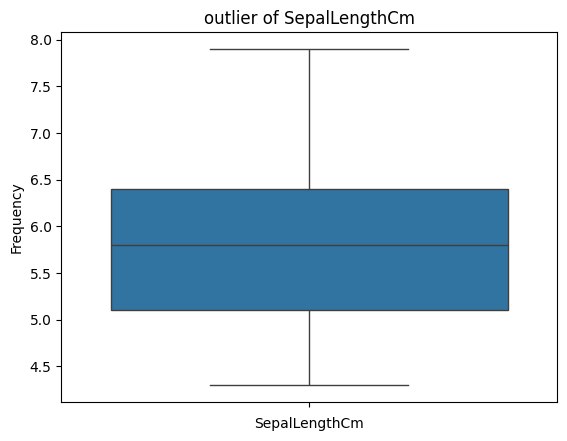

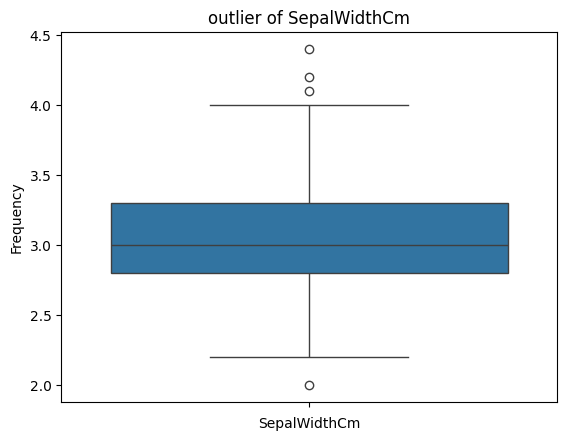

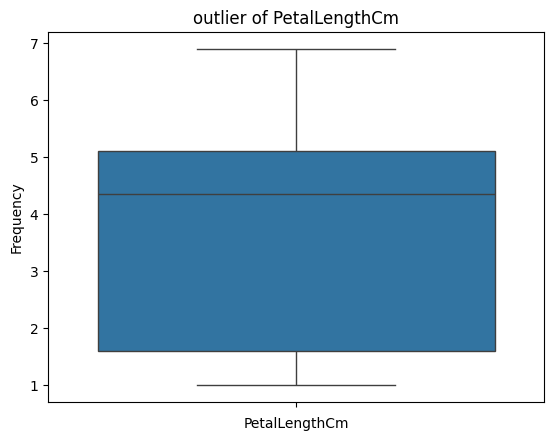

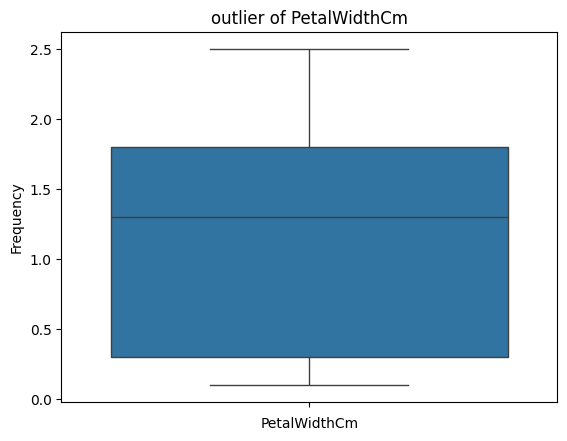

In [ ]:
num_col = data.select_dtypes(include=np.number).columns
for col in num_col:
  plt.figure()
  sns.boxplot(data[col])
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(f'outlier of {col}')
  plt.show()

In [ ]:
for col in num_col:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

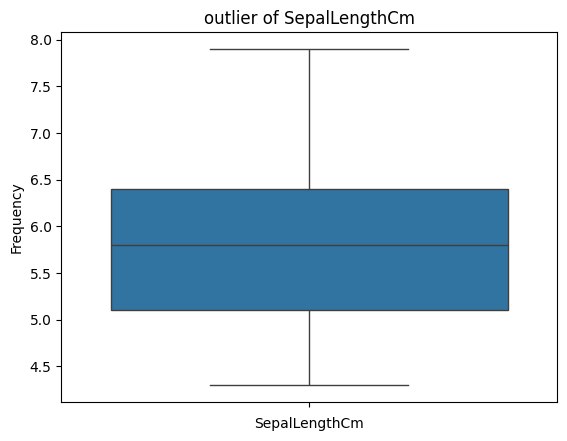

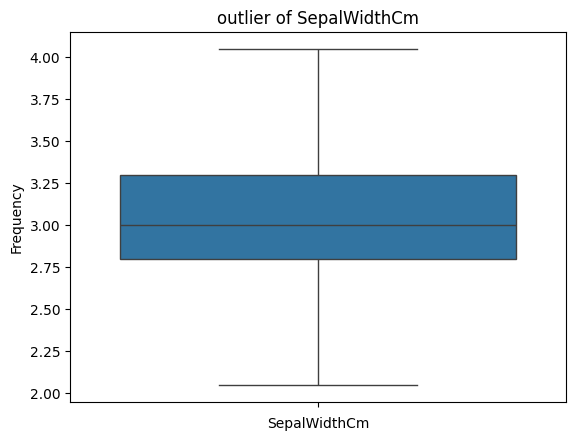

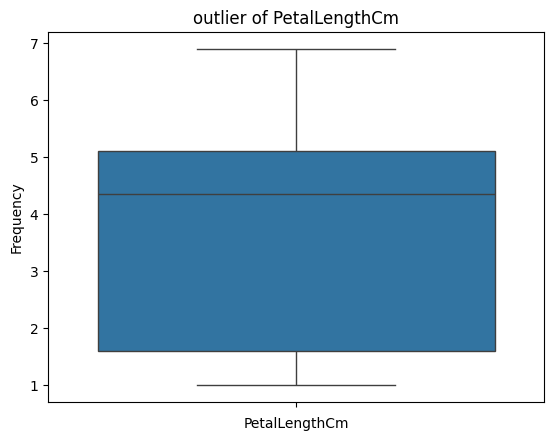

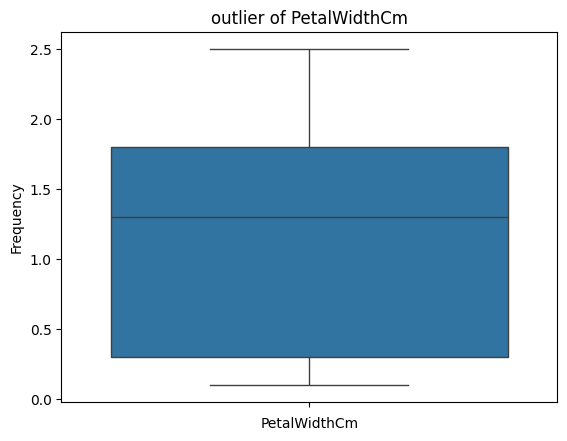

In [ ]:
for col in num_col:
  plt.figure()
  sns.boxplot(data[col])
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(f'outlier of {col}')
  plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [ ]:
wcss = []
for i in range(1,11):
  km = KMeans(n_clusters=i,random_state=42)
  km.fit(X_scaled)
  wcss.append(km.inertia_)

<function matplotlib.pyplot.show(close=None, block=None)>

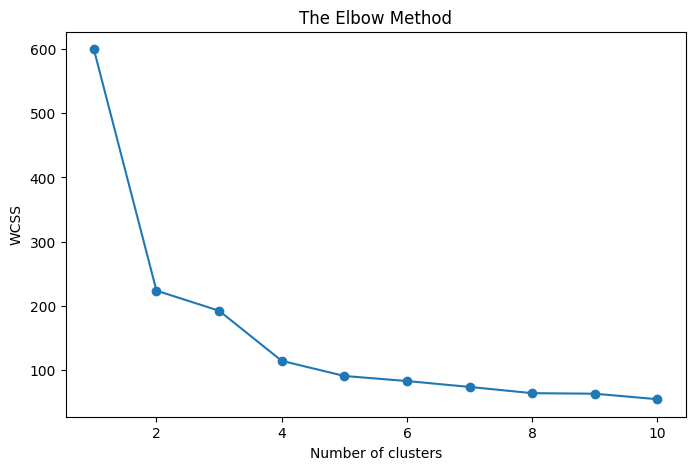

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker ='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show

In [ ]:
km = KMeans(
    n_clusters=2,
    random_state=42)

In [ ]:
y_means = km.fit_predict(X_scaled)

In [ ]:
data['cluster']=y_means

In [ ]:
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [ ]:
cluster_profile = data.groupby('cluster').mean()
cluster_profile

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
cluster,,,,
0,6.262,2.8725,4.906,1.676
1,5.006,3.4070,1.464,0.244


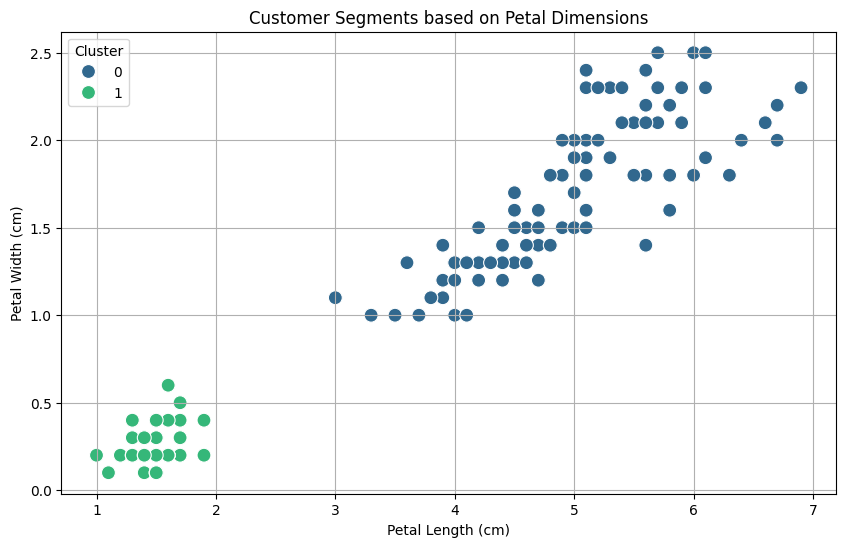

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=data['PetalLengthCm'],
    y=data['PetalWidthCm'],
    hue=data['cluster'],
    palette='viridis',
    s=100
)
plt.title("Customer Segments based on Petal Dimensions")
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
score = silhouette_score(X_scaled,y_means)
print ('silhouette_score:' , score)

silhouette_score: 0.5798857604435109
